# Notebook 06 — Multimodal Training

This notebook covers the multimodal phase of the project. The selected backbone is **EfficientNet-B0 (none)** combined with clinical metadata via **Late Fusion**.

## Late Fusion Architecture - 7 Experiments
| Exp | Metadata | Dim |
|-----|----------|-----|
| e01 | sex | 3 |
| e02 | age | 1 |
| e03 | localization | 15 |
| e04 | sex + age | 4 |
| e05 | sex + localization | 18 |
| e06 | age + localization | 16 |
| e07 | sex + age + localization | 19 |

The final comparison against the unimodal baseline (**B0 none, Val AUC 0.9593**) is at the end of this notebook. In-depth evaluation of the best model goes in **Notebook 07**.

In [2]:
import sys
sys.path.append('..')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.config import METRICS_DIR, FIGURES_DIR, OUTPUTS_DIR

LOGS_DIR = os.path.join(OUTPUTS_DIR, 'logs')

print("Imports OK")

Imports OK


In [3]:
import subprocess

def launch_experiment(config_name):
    log_path = os.path.join(LOGS_DIR, f"{config_name}.log")
    cmd = (
        f"cd .. && nohup python experiments/run.py "
        f"--config experiments/configs/{config_name}.yaml "
        f"> {log_path} 2>&1 &"
    )
    subprocess.Popen(cmd, shell=True)
    print(f"Launched: {config_name}")
    print(f"Monitor:  tail -f {log_path}")

def monitor_experiment(config_name):
    log_path = os.path.join(LOGS_DIR, f"{config_name}.log")
    os.system(f"tail -20 {log_path}")

def is_finished(config_name):
    record_path = os.path.join(METRICS_DIR, f"{config_name}_record.json")
    finished = os.path.exists(record_path)
    status = "✅ Finished" if finished else "⏳ Running or not started"
    print(f"{config_name}: {status}")
    return finished


## Multimodal Experiments

All experiments use **EfficientNet-B0 + no preprocessing** as backbone.
Since the experiments have already been run, the cells below are kept for reproducibility only.

### Experiment 01 — B0 + None + sex

In [ ]:
launch_experiment('multimodal_e01_sex')

### Experiment 02 — B0 + None + age

In [ ]:
launch_experiment('multimodal_e02_age')

### Experiment 03 — B0 + None + localization

In [ ]:
launch_experiment('multimodal_e03_loc')

### Experiment 04 — B0 + None + sex + age

In [ ]:
launch_experiment('multimodal_e04_sex_age')

### Experiment 05 — B0 + None + sex + localization

In [ ]:
launch_experiment('multimodal_e05_sex_loc')

### Experiment 06 — B0 + None + age + localization

In [ ]:
launch_experiment('multimodal_e06_age_loc')

### Experiment 07 — B0 + None + sex + age + localization

In [ ]:
launch_experiment('multimodal_e07_all')

---
## Quick Comparison — Multimodal vs Unimodal Baseline

A first overview of the 7 multimodal experiments against the unimodal baseline (**B0 none, Val AUC 0.9593**).
Full in-depth evaluation (test set metrics, confusion matrices, ROC curves) is covered in **Notebook 07**.

In [5]:
EXPERIMENTS = {
    'multimodal_b0_none_sex':                 'e01 — sex',
    'multimodal_b0_none_age':                 'e02 — age',
    'multimodal_b0_none_localization':        'e03 — localization',
    'multimodal_b0_none_sex_age':             'e04 — sex + age',
    'multimodal_b0_none_sex_localization':    'e05 — sex + loc',
    'multimodal_b0_none_age_localization':    'e06 — age + loc',
    'multimodal_b0_none_sex_age_localization':'e07 — all',
}

BASELINE = {'label': 'Baseline — B0 none (unimodal)', 'mean_auc': 0.9593, 'std_auc': 0.0028}

results = []
for exp_name, label in EXPERIMENTS.items():
    summary_path = os.path.join(METRICS_DIR, f"{exp_name}_summary.csv")
    if os.path.exists(summary_path):
        df_s = pd.read_csv(summary_path)
        results.append({
            'experiment': label,
            'mean_auc': df_s['mean_auc'].values[0],
            'std_auc':  df_s['std_auc'].values[0],
        })
    else:
        print(f"⚠️  Not found: {summary_path}")

df_results = pd.DataFrame(results).sort_values('mean_auc', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

        experiment  mean_auc  std_auc
   e06 — age + loc  0.964441 0.003282
   e04 — sex + age  0.963680 0.003331
         e07 — all  0.963611 0.002652
e03 — localization  0.963348 0.001641
   e05 — sex + loc  0.962843 0.002701
         e02 — age  0.962213 0.004000
         e01 — sex  0.960859 0.002160


In [6]:
baseline_row = pd.DataFrame([{
    'experiment': BASELINE['label'],
    'mean_auc':   BASELINE['mean_auc'],
    'std_auc':    BASELINE['std_auc'],
}])

df_display = pd.concat([df_results, baseline_row], ignore_index=True)
df_display['Val AUC (mean ± std)'] = df_display.apply(
    lambda r: f"{r['mean_auc']:.4f} ± {r['std_auc']:.4f}", axis=1
)
print(df_display[['experiment', 'Val AUC (mean ± std)']].to_string(index=False))

                   experiment Val AUC (mean ± std)
              e06 — age + loc      0.9644 ± 0.0033
              e04 — sex + age      0.9637 ± 0.0033
                    e07 — all      0.9636 ± 0.0027
           e03 — localization      0.9633 ± 0.0016
              e05 — sex + loc      0.9628 ± 0.0027
                    e02 — age      0.9622 ± 0.0040
                    e01 — sex      0.9609 ± 0.0022
Baseline — B0 none (unimodal)      0.9593 ± 0.0028


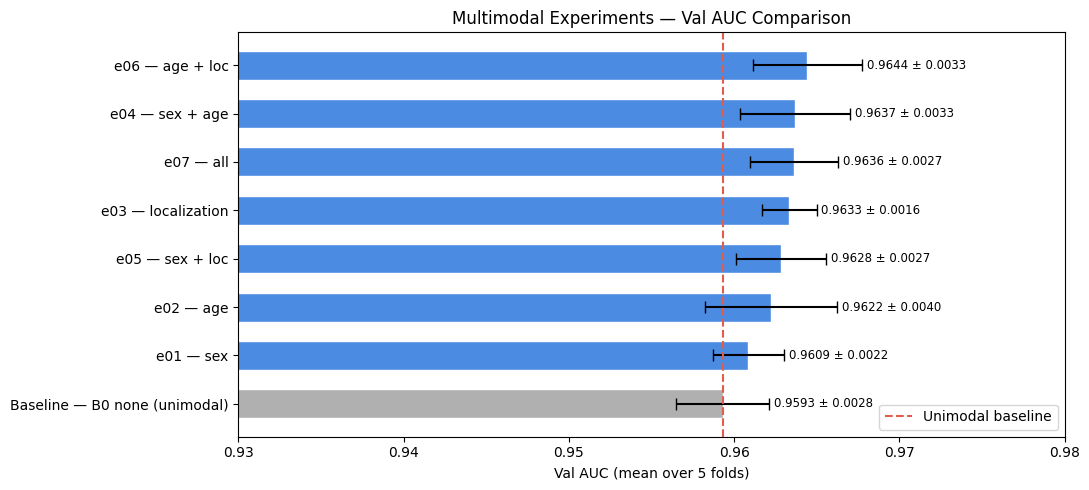

Saved: multimodal_auc_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

df_display_sorted = df_display.sort_values('mean_auc', ascending=True)

colors = ['#B0B0B0' if 'unimodal' in r else '#4C8BE2' for r in df_display_sorted['experiment']]

ax.barh(
    df_display_sorted['experiment'],
    df_display_sorted['mean_auc'],
    xerr=df_display_sorted['std_auc'],
    color=colors,
    edgecolor='white',
    capsize=4,
    height=0.6
)

for i, (_, row) in enumerate(df_display_sorted.iterrows()):
    ax.text(
        row['mean_auc'] + row['std_auc'] + 0.0003,
        i,
        f"{row['mean_auc']:.4f} ± {row['std_auc']:.4f}",
        va='center', fontsize=8.5
    )

ax.axvline(BASELINE['mean_auc'], color='#E25C4C', linestyle='--', linewidth=1.5, label='Unimodal baseline')
ax.set_xlabel('Val AUC (mean over 5 folds)')
ax.set_title('Multimodal Experiments — Val AUC Comparison')
ax.legend(loc='lower right')
ax.set_xlim(0.93, 0.980)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'multimodal_auc_comparison.png'), dpi=150)
plt.show()
print("Saved: multimodal_auc_comparison.png")

## Conclusions

- All 7 multimodal experiments outperform the unimodal baseline (Val AUC 0.9593)
- Best experiment: **e06 — age + localization** (Val AUC 0.9644 ± 0.0033)
- Adding `sex` alone provides the smallest improvement (e01, AUC 0.9609)
- `age` and `localization` are the most informative metadata features, consistent with EDA findings (age-diagnosis correlation: -0.428)
- Full evaluation on the test set (confusion matrix, ROC curves, per-class metrics) → **Notebook 07**